# Grid-cell Time of Emergence — UKESM1-1 annual-mean TAS
## G6-1.5K-SAI and G6-1.5K-HiLLA vs SSP2-4.5

**Method (as in `ToE_GMSAT_ttest`, applied per grid cell):** For each paired member
(geoengineering-scenario member vs its matched SSP2-4.5 realisation) and each grid cell,
apply the cumulative one-sided Welch's t-test (`scenario < SSP2-4.5`, i.e. local cooling
relative to the counterfactual) to annual-mean TAS over the window [2035, Y], p < 0.05.
**Member ToE** (per cell) = first year Y ≥ 2035 at which the test is significant, locked
thereafter. **Map value ("p66")** = 2nd-earliest of the 3 member ToEs per cell
(k = ⌈0.66 × 3⌉ = 2, the same count-based rule as the global analysis). Cells where fewer
than 2 members emerge by the end of the record are shown in grey ("no emergence").

**Output:** two Robinson-projection maps — G6-1.5K-SAI (left) and G6-1.5K-HiLLA (right) —
sharing one colourbar.

Note the one-sided *cooling* test means regions where SAI/HiLLA locally *warm* relative to
SSP2-4.5 (e.g. possible winter Eurasia warming) will correctly appear as "no emergence"
rather than emerging with the wrong sign.

In [1]:
import fsspec
import s3fs
import xarray as xr
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from scipy import stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

matplotlib.rcParams.update({'font.size': 13})

SAI_START = 2035
ALPHA     = 0.05
MIN_N     = 2      # minimum years in the cumulative window
K_OF_N    = 2      # p66 for N=3: 2nd-earliest member ToE per cell

## 1. File paths (as in `ToE_GMSAT_ttest`)

In [2]:
_UKESM_HiLLA  = 's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA'
_UKESM_SSP245 = 's3://reflective-persistent-prod-large/UKESM1-1/SSP245'
_UKESM_SAI    = 's3://reflective-persistent-prod/alistairduffey/UKESM1-1/G6-1.5K-SAI'

ukesm_hilla_members  = ['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2']
ukesm_ssp245_members = ['r12i1p1f1', 'r2i1p1f1', 'r3i1p1f1']

ukesm_hilla_paths  = [f'{_UKESM_HiLLA}/{m}/apm/Amon/tas/'  for m in ukesm_hilla_members]
ukesm_ssp245_paths = [f'{_UKESM_SSP245}/{m}/ap5/Amon/tas/' for m in ukesm_ssp245_members]
ukesm_sai_paths    = [f'{_UKESM_SAI}/r{i+1}/AMON/'         for i in range(3)]

print('File paths defined.')

File paths defined.


## 2. Data loading — full monthly TAS fields

In [3]:
def open_mf_from_path(s3_dir, drop_year=None):
    fs = s3fs.S3FileSystem(anon=False)
    files = sorted(fs.ls(s3_dir.replace('s3://', '')))
    file_objs = [fsspec.open(f's3://{f}', mode='rb').open() for f in files]
    ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()
    if drop_year is not None:
        ds = ds.sel(time=(ds.time.dt.year != drop_year))
    return ds


def open_ukesm_sai(path_list):
    """UKESM G6-1.5K-SAI files have non-standard dims (t/temp/ht) and
    latitude/longitude coordinate names — fix them up to time/tas/lat/lon."""
    ds_list = []
    for path in path_list:
        files = fsspec.open_files(f'{path}*.nc', mode='rb')
        ds = xr.open_mfdataset([f.open() for f in files],
                               combine='nested', concat_dim='time', chunks={}).load()
        ds = ds.isel(time=0).rename({'t': 'time'}).rename({'temp': 'tas'}).isel(ht=0)
        if 'latitude' in ds.dims:
            ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_list.append(ds)
    return ds_list


def normalise(ds):
    """Standardise coord names, keep only tas, sort lat ascending."""
    if 'latitude' in ds.dims:
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
    da = ds['tas']
    if float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby('lat')
    return da


print('Loading UKESM1-1 G6-1.5K-HiLLA...')
hilla_ds  = [open_mf_from_path(p, drop_year=2084) for p in ukesm_hilla_paths]   # missing Dec 2084
print('Loading UKESM1-1 SSP2-4.5...')
ssp245_ds = [open_mf_from_path(p).pipe(lambda d: d.sel(time=d.time.dt.year >= 2025))
             for p in ukesm_ssp245_paths]
print('Loading UKESM1-1 G6-1.5K-SAI...')
sai_ds    = open_ukesm_sai(ukesm_sai_paths)

hilla_tas  = [normalise(ds) for ds in hilla_ds]
ssp245_tas = [normalise(ds) for ds in ssp245_ds]
sai_tas    = [normalise(ds) for ds in sai_ds]
print(f'HiLLA {len(hilla_tas)}, SSP245 {len(ssp245_tas)}, SAI {len(sai_tas)} members')

Loading UKESM1-1 G6-1.5K-HiLLA...


/tmp/ipykernel_619/3337409606.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()
/tmp/ipykernel_619/3337409606.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_

Loading UKESM1-1 SSP2-4.5...


/tmp/ipykernel_619/3337409606.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()
/tmp/ipykernel_619/3337409606.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_objs, combine='nested', concat_

Loading UKESM1-1 G6-1.5K-SAI...


/tmp/ipykernel_619/3337409606.py:17: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset([f.open() for f in files],
/tmp/ipykernel_619/3337409606.py:17: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset([f.open() for f in files],
/tmp/ipykernel_619/3337409606.py:17: FutureWarning: In a future version of

HiLLA 3, SSP245 3, SAI 3 members


In [4]:
# ── Grid consistency check ────────────────────────────────────────────────────
# The SAI files come from a different pipeline; verify all three scenarios are on the
# same N96 grid before doing any cell-wise arithmetic. If this fails, the SAI fields
# need regridding to the HiLLA grid first.
ref = hilla_tas[0]
for name, das in [('HiLLA', hilla_tas), ('SSP245', ssp245_tas), ('SAI', sai_tas)]:
    for i, da in enumerate(das):
        assert da.lat.size == ref.lat.size and da.lon.size == ref.lon.size, \
            f'{name} r{i+1}: grid shape {da.lat.size}x{da.lon.size} != {ref.lat.size}x{ref.lon.size}'
        assert np.allclose(da.lat.values, ref.lat.values, atol=1e-4), f'{name} r{i+1}: lat mismatch'
        assert np.allclose(da.lon.values, ref.lon.values, atol=1e-4), f'{name} r{i+1}: lon mismatch'
print(f'All members on the same {ref.lat.size} x {ref.lon.size} grid.')

All members on the same 144 x 192 grid.


## 3. Month-length-weighted annual means per grid cell

In [5]:
def annual_mean_field(da):
    """Month-length-weighted annual mean of a (time, lat, lon) monthly field.
    Incomplete years (< 12 months) are dropped. Returns (year, lat, lon)."""
    w   = da.time.dt.days_in_month
    num = (da * w).groupby('time.year').sum('time')
    den = w.groupby('time.year').sum('time')
    ann = num / den
    cnt = w.groupby('time.year').count()
    ann = ann.sel(year=cnt[cnt == 12].year)
    return ann.assign_coords(year=ann.year.values.astype(int))


print('Computing annual means...')
hilla_ann  = [annual_mean_field(da) for da in hilla_tas]
ssp245_ann = [annual_mean_field(da) for da in ssp245_tas]
sai_ann    = [annual_mean_field(da) for da in sai_tas]

for name, das in [('HiLLA', hilla_ann), ('SSP245', ssp245_ann), ('SAI', sai_ann)]:
    for i, da in enumerate(das):
        print(f'  {name:<7} r{i+1}: {int(da.year[0])}-{int(da.year[-1])}  '
              f'global-ish mean {float(da.mean()):.1f} K')

Computing annual means...
  HiLLA   r1: 2034-2083  global-ish mean 279.9 K
  HiLLA   r2: 2034-2083  global-ish mean 279.9 K
  HiLLA   r3: 2034-2083  global-ish mean 279.9 K
  SSP245  r1: 2025-2100  global-ish mean 281.6 K
  SSP245  r2: 2025-2100  global-ish mean 281.6 K
  SSP245  r3: 2025-2100  global-ish mean 281.6 K
  SAI     r1: 2034-2084  global-ish mean 0.0 K
  SAI     r2: 2034-2084  global-ish mean 0.0 K
  SAI     r3: 2034-2084  global-ish mean 0.0 K


## 4. Grid-cell cumulative one-sided t-test

Vectorised over the grid: for each candidate year Y, compute the Welch t-statistic and
one-sided p-value (`scenario < SSP2-4.5`) at every cell from the cumulative windows
[2035, Y] of both simulations. A cell's member ToE is the first Y with p < 0.05, locked
once reached (exactly the per-member behaviour of the scalar `cumulative_ttest_toe`).

In [6]:
def cumulative_ttest_toe_map(scen_ann, ssp_ann, start_year=SAI_START,
                             alpha=ALPHA, min_n=MIN_N):
    """Per-grid-cell cumulative one-sided Welch's t-test ToE (scen < ssp).
    scen_ann, ssp_ann: (year, lat, lon) DataArrays. Returns (lat, lon) DataArray of
    member ToE years, NaN where the cell never emerges."""
    g = scen_ann.sel(year=scen_ann.year >= start_year)
    s = ssp_ann.sel(year=ssp_ann.year >= start_year)
    g_yrs, s_yrs = g.year.values, s.year.values
    gv, sv = g.values, s.values                      # (nyears, nlat, nlon)
    end_year = int(min(g_yrs.max(), s_yrs.max()))

    toe       = np.full(gv.shape[1:], np.nan)
    undecided = np.ones(gv.shape[1:], dtype=bool)

    for Y in range(start_year, end_year + 1):
        gw, sw = gv[g_yrs <= Y], sv[s_yrs <= Y]
        n1, n2 = gw.shape[0], sw.shape[0]
        if min(n1, n2) < min_n:
            continue
        m1, m2 = gw.mean(axis=0), sw.mean(axis=0)
        v1 = gw.var(axis=0, ddof=1)
        v2 = sw.var(axis=0, ddof=1)
        with np.errstate(divide='ignore', invalid='ignore'):
            se2 = v1 / n1 + v2 / n2
            t   = (m1 - m2) / np.sqrt(se2)
            df  = se2**2 / ((v1 / n1)**2 / (n1 - 1) + (v2 / n2)**2 / (n2 - 1))
            p   = stats.t.cdf(t, df)                 # one-sided 'less'
        newly = undecided & (p < alpha)
        toe[newly] = Y
        undecided &= ~newly
        if not undecided.any():
            break

    return xr.DataArray(toe, coords={'lat': scen_ann.lat, 'lon': scen_ann.lon},
                        dims=('lat', 'lon')), end_year


def p66_map(member_maps, k=K_OF_N):
    """k-th earliest member ToE per cell; NaN where fewer than k members emerged.
    np.sort places NaNs last, so index k-1 is exactly the k-th earliest."""
    stacked = np.stack([m.values for m in member_maps])
    with np.errstate(invalid='ignore'):
        srt = np.sort(stacked, axis=0)
    out = srt[k - 1]
    return xr.DataArray(out, coords=member_maps[0].coords, dims=member_maps[0].dims)


print('Computing member ToE maps (SAI)...')
sai_member_maps, sai_end = zip(*[cumulative_ttest_toe_map(sai_ann[i], ssp245_ann[i])
                                 for i in range(3)])
print('Computing member ToE maps (HiLLA)...')
hilla_member_maps, hilla_end = zip(*[cumulative_ttest_toe_map(hilla_ann[i], ssp245_ann[i])
                                     for i in range(3)])

toe_maps = {
    'G6-1.5K-SAI':   p66_map(list(sai_member_maps)),
    'G6-1.5K-HiLLA': p66_map(list(hilla_member_maps)),
}
END_YEAR = {'G6-1.5K-SAI': min(sai_end), 'G6-1.5K-HiLLA': min(hilla_end)}
print(f'End years: {END_YEAR}')

Computing member ToE maps (SAI)...
Computing member ToE maps (HiLLA)...
End years: {'G6-1.5K-SAI': 2084, 'G6-1.5K-HiLLA': 2083}


In [7]:
# ── Area-weighted summary ─────────────────────────────────────────────────────
w2d = np.cos(np.deg2rad(toe_maps['G6-1.5K-SAI'].lat)).broadcast_like(toe_maps['G6-1.5K-SAI'])

print(f'{"Scenario":<16}{"% area emerged":>16}{"area-wtd median ToE":>22}')
for scen, tm in toe_maps.items():
    emerged = np.isfinite(tm.values)
    frac = float(w2d.values[emerged].sum() / w2d.values.sum()) * 100
    if emerged.any():
        # weighted median over emerged cells
        vals = tm.values[emerged]; ws = w2d.values[emerged]
        order = np.argsort(vals)
        cw = np.cumsum(ws[order]) / ws[order].sum()
        med = vals[order][np.searchsorted(cw, 0.5)]
        print(f'{scen:<16}{frac:>15.1f}%{med:>22.0f}')
    else:
        print(f'{scen:<16}{frac:>15.1f}%{"—":>22}')

Scenario          % area emerged   area-wtd median ToE
G6-1.5K-SAI               100.0%                  2036
G6-1.5K-HiLLA             100.0%                  2044


## 5. Figure — Robinson maps of grid-cell ToE

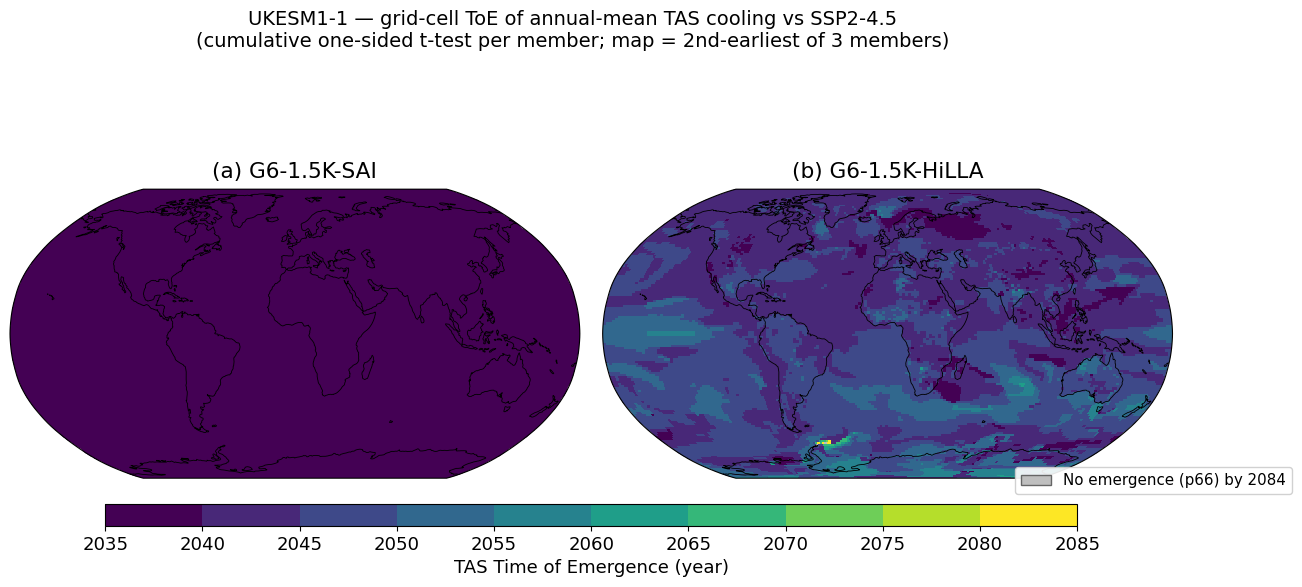

In [14]:
NO_EMERGE_COL = '#BFBFBF'
CMAP_NAME     = 'viridis'

vmin = SAI_START
vmax = max(END_YEAR.values()) + 1          # upper bin edge
bounds = np.arange(vmin, vmax + 1, 5)
if bounds[-1] < vmax:
    bounds = np.append(bounds, vmax)
cmap = plt.get_cmap(CMAP_NAME, len(bounds) - 1).copy()
cmap.set_bad(NO_EMERGE_COL)
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         subplot_kw={'projection': ccrs.Robinson()})
fig.subplots_adjust(wspace=0.04, bottom=0.16)

panel_labels = ['(a)', '(b)']
mesh = None
for ax, plabel, scen in zip(axes, panel_labels, ['G6-1.5K-SAI', 'G6-1.5K-HiLLA']):
    tm = toe_maps[scen]
    tm = tm.assign_coords(lon=(((tm.lon + 180) % 360) - 180)).sortby('lon')
    mesh = ax.pcolormesh(tm.lon.values, tm.lat.values, tm.values,
                         transform=ccrs.PlateCarree(), cmap=cmap, norm=norm,
                         shading='auto', rasterized=True)

    ax.coastlines(lw=0.6, color='k')
    ax.set_global()
    ax.set_title(f'{plabel} {scen}', fontsize='large', pad=8)

cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal',
                    fraction=0.05, pad=0.06, aspect=45, extend='neither',
                    ticks=bounds)
cbar.set_label('TAS Time of Emergence (year)', fontsize='medium')

# 'no emergence' legend entry
fig.legend(handles=[Patch(facecolor=NO_EMERGE_COL, edgecolor='0.4',
                          label=f'No emergence (p66) by {max(END_YEAR.values())}')],
           loc='lower right', bbox_to_anchor=(0.985, 0.20),
           fontsize='small', framealpha=0.9)

fig.suptitle('UKESM1-1 — grid-cell ToE of annual-mean TAS cooling vs SSP2-4.5\n'
             '(cumulative one-sided t-test per member; map = 2nd-earliest of 3 members)',
             fontsize=14, y=1.02)

plt.savefig('Figures/UKESM_gridcell_ToE_maps.png', dpi=200, bbox_inches='tight')
plt.show()

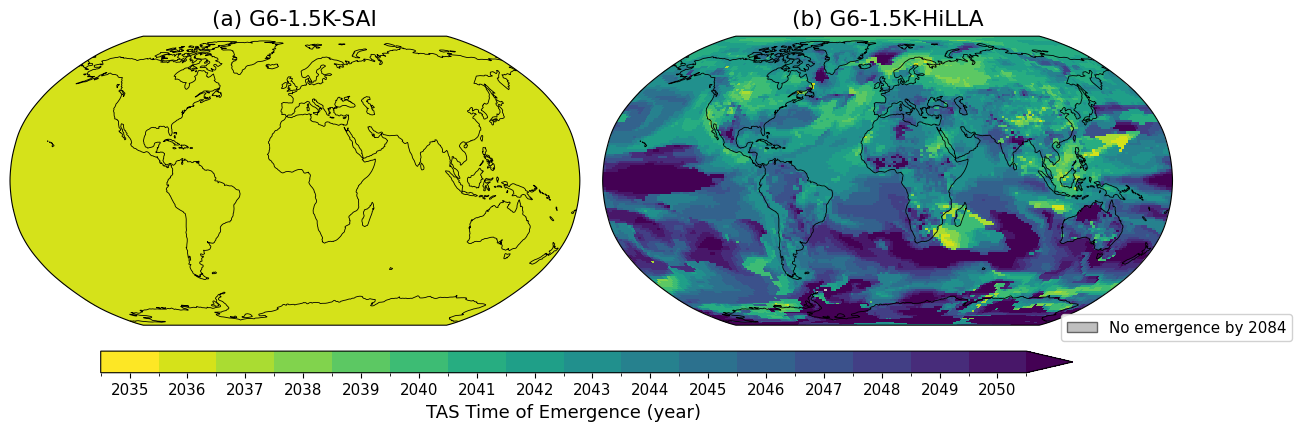

In [17]:
NO_EMERGE_COL = '#BFBFBF'
CMAP_NAME     = 'viridis_r'

# One bin per year, 2035–2050: edges at half-years so integer ToE values fall
# mid-bin. Values > 2050 go to the 'over' colour (one-sided colorbar arrow).
bounds = np.arange(2034.5, 2051.0, 1.0)                    # 2034.5 ... 2050.5
cmap   = plt.get_cmap(CMAP_NAME, len(bounds)).copy()       # n_bins + 1 (extra for 'over')
cmap.set_bad(NO_EMERGE_COL)
norm   = BoundaryNorm(bounds, cmap.N, extend='max')

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         subplot_kw={'projection': ccrs.Robinson()})
fig.subplots_adjust(wspace=0.04, bottom=0.16)

panel_labels = ['(a)', '(b)']
mesh = None
for ax, plabel, scen in zip(axes, panel_labels, ['G6-1.5K-SAI', 'G6-1.5K-HiLLA']):
    # Roll longitudes 0..360 -> -180..180 so no cell crosses the Robinson
    # (central_longitude=0) seam. Cartopy's pcolormesh seam-wrapping masks the
    # wrapped cells and requires the cmap's 'bad' colour to be transparent —
    # incompatible with our opaque grey set_bad — so we avoid wrapping entirely.
    tm = toe_maps[scen]
    tm = tm.assign_coords(lon=(((tm.lon + 180) % 360) - 180)).sortby('lon')
    mesh = ax.pcolormesh(tm.lon.values, tm.lat.values, tm.values,
                         transform=ccrs.PlateCarree(), cmap=cmap, norm=norm,
                         shading='auto', rasterized=True)
    ax.coastlines(lw=0.6, color='k')
    ax.set_global()
    ax.set_title(f'{plabel} {scen}', fontsize='large', pad=8)

cbar = fig.colorbar(mesh, ax=axes, orientation='horizontal',
                    fraction=0.05, pad=0.06, aspect=45, extend='max',
                    ticks=np.arange(2035, 2051))
cbar.set_label('TAS Time of Emergence (year)', fontsize='medium')
cbar.ax.tick_params(labelsize='small')

# 'no emergence' legend entry
fig.legend(handles=[Patch(facecolor=NO_EMERGE_COL, edgecolor='0.4',
                          label=f'No emergence by {max(END_YEAR.values())}')],
           loc='lower right', bbox_to_anchor=(0.985, 0.20),
           fontsize='small', framealpha=0.9)

#fig.suptitle('UKESM1-1 — grid-cell ToE of annual-mean TAS cooling vs SSP2-4.5\n'
#             '(cumulative one-sided t-test per member; map = 2nd-earliest of 3 members)',
#             fontsize=14, y=1.02)

plt.savefig('Figures/UKESM_gridcell_ToE_maps.png', dpi=200, bbox_inches='tight')
plt.show()